In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

In [57]:
dataset_path = Path('data/nodes/6nodes_serverset.csv')
df = pd.read_csv(dataset_path,  dtype={'run_id': str})

In [58]:
mask72 = (
    (df['tdd'] == '7-2') &
    (df['distribution'] == 'dirichlet') &
    (df['rank']== '2x2') &
    (df['network'] == 'wwan') &
    (df['nodes'] == '6N')
)
df72 = df[mask72].copy()

In [59]:
data_size = 2.9172 * 8
df['ul_throughput'] = data_size / df['uplink_latency']
df['dl_throughput'] = data_size / df['downlink_latency']

In [60]:
mu = 1
T_s = 1e-3 / (14 *2 ** mu)
R_max = 948 / 1024
f = 1
OH_dl = 0.14
OH_ul = 0.08
v_layers = 2

N_PRB = {'20 MHz': 51, '40 MHz': 106, '60 MHz': 162,'80 MHz': 217, '100 MHz': 273}

def theoretical_throughput(bw, Qm, direction='dl'):
    oh = OH_dl if direction == 'dl' else OH_ul
    return 1e-6 * v_layers * Qm * f * R_max * ((N_PRB[bw] * 12) / T_s) * (1 - oh)

bandwidths = ['20 MHz', '40 MHz', '80 MHz', '100 MHz']

def get_scale_factor(df, direction, tput_col, qm_col):
    s = df[df['bandwidth'] == '100 MHz']
    if s.empty:
        return 1
    avg_qm = s[qm_col].mean()
    theo = theoretical_throughput('100 MHz', avg_qm, direction)
    measured = s[tput_col].mean()
    return measured / theo

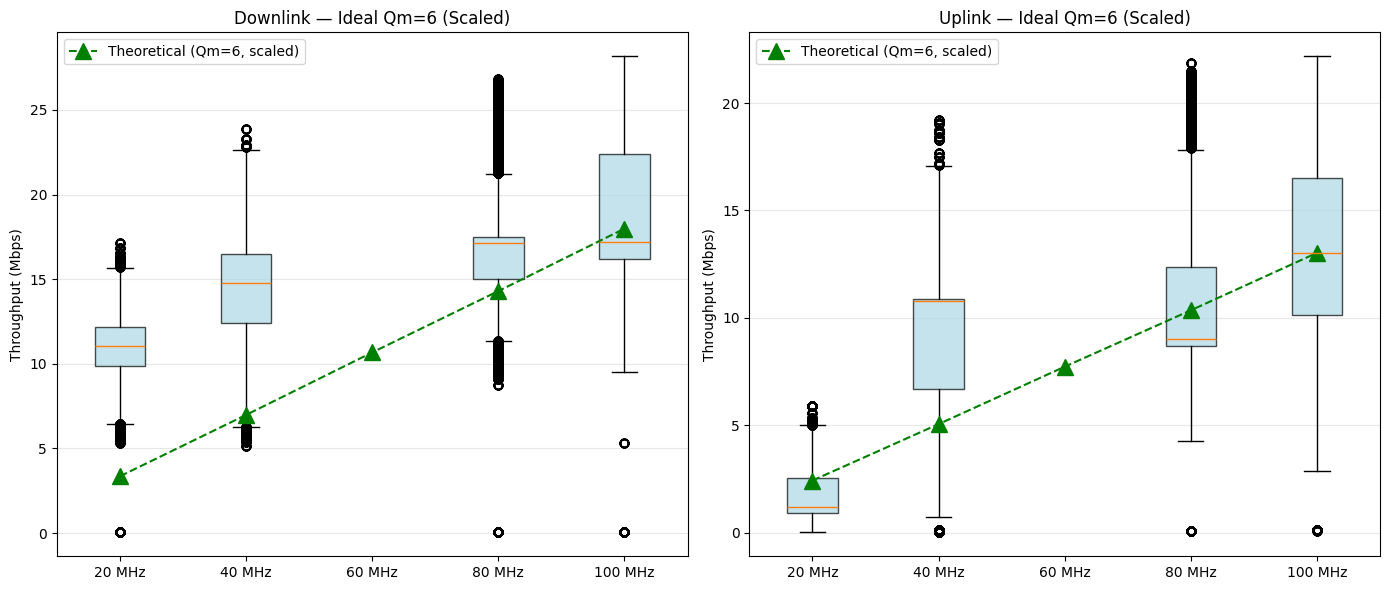

In [65]:
# --- Figure 2: Ideal Qm=6, scaled to experiment ---
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 6))

bandwidths_with_60 = ['20 MHz', '40 MHz', '60 MHz', '80 MHz', '100 MHz']
N_PRB['60 MHz'] = 162

for ax, direction, tput_col, label in zip(
    axes2, ['dl', 'ul'], ['dl_throughput', 'ul_throughput'],
    ['Downlink', 'Uplink']
):
    s100 = df[df['bandwidth'] == '100 MHz']
    if not s100.empty:
        theo_100 = theoretical_throughput('100 MHz', 6, direction)
        measured_100 = s100[tput_col].mean()
        scale = measured_100 / theo_100
    else:
        scale = 1

    box_data = []
    box_positions = []
    tick_labels = []
    theo_vals = []
    theo_positions = []

    pos = 0
    for bw in bandwidths_with_60:
        subset = df[df['bandwidth'] == bw]
        if not subset.empty:
            box_data.append(subset[tput_col].dropna().values)
            box_positions.append(pos)
        theo_vals.append(theoretical_throughput(bw, 6, direction) * scale)
        theo_positions.append(pos)
        tick_labels.append(bw)
        pos += 1

    ax.boxplot(box_data, positions=box_positions, widths=0.4, patch_artist=True,
               boxprops=dict(facecolor='lightblue', alpha=0.7))
    ax.plot(theo_positions, theo_vals, 'g^--', markersize=12, label='Theoretical (Qm=6, scaled)')

    ax.set_xticks(theo_positions)
    ax.set_xticklabels(tick_labels)
    ax.set_ylabel('Throughput (Mbps)')
    ax.set_title(f'{label} — Ideal Qm=6 (Scaled)')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('throughput_ideal_qm_scaled.png', dpi=150)
plt.show()

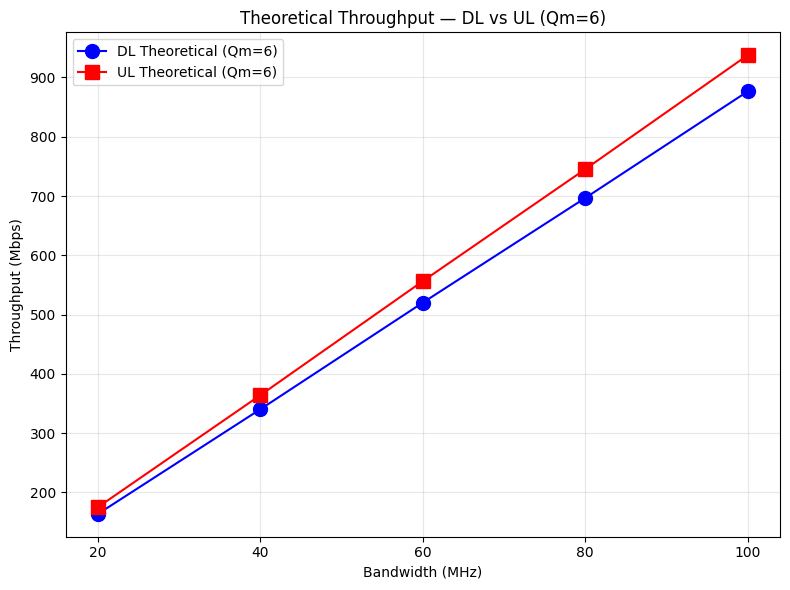

In [62]:
# --- Figure 3: Theoretical only ---
fig3, ax3 = plt.subplots(figsize=(8, 6))

bw_mhz = [20, 40, 60, 80, 100]
N_PRB_full = {20: 51, 40: 106, 60: 162, 80: 217, 100: 273}

def theo_full(bw, direction='dl'):
    oh = OH_dl if direction == 'dl' else OH_ul
    return 1e-6 * v_layers * 6 * f * R_max * (N_PRB_full[bw] * 12 / T_s) * (1 - oh)

theo_dl = [theo_full(bw, 'dl') for bw in bw_mhz]
theo_ul = [theo_full(bw, 'ul') for bw in bw_mhz]

ax3.plot(bw_mhz, theo_dl, 'bo-', markersize=10, label='DL Theoretical (Qm=6)')
ax3.plot(bw_mhz, theo_ul, 'rs-', markersize=10, label='UL Theoretical (Qm=6)')

ax3.set_xlabel('Bandwidth (MHz)')
ax3.set_ylabel('Throughput (Mbps)')
ax3.set_xticks(bw_mhz)
ax3.set_title('Theoretical Throughput — DL vs UL (Qm=6)')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('throughput_theoretical.png', dpi=150)
plt.show()